In [198]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [199]:
l = serial.Serial()
l.port="/dev/ttyUSB1"
l.baudrate = 115200
l.bytesize = 8
l.open()
l.close()



In [200]:
import random as rd
import time

In [201]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [202]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*10**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*10**(BitsPorSimbolo))
  return [Ain,Bin]

In [203]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [204]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [205]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [206]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")


  s = serial.Serial()
  s.port = "/dev/ttyUSB1"
  s.baudrate = 115200
  s.bytesize = 8
  s.open()
  Fs =1000
  cmp = len(str(X[0][0]))
  #file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray(X[j][i]))
    #print('0b'+strbin,i)
    #print(int('0b'+strbin,2))
    #file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
      time.sleep(1/Fs)  
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.write(bytearray([0]))
  s.close()  
  #file.close()
 

In [207]:
M = create_matrix(Din = 8, BitsPorSimbolo=np.log2(1))
#print_matrix(M[1])


In [208]:
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"IMPUT_A",1)
    send_matrix(M_p[1],"IMPUT_B",1)
    
    break
    time.sleep(10)

---------------------- 0 --------------------------


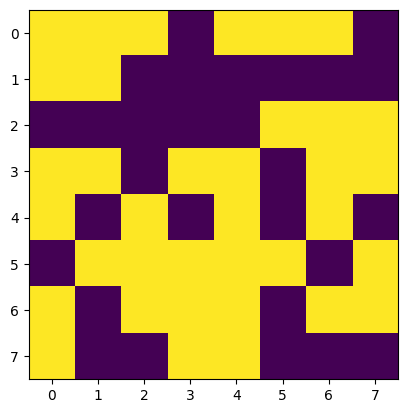

In [209]:
plt.imshow(M[1])

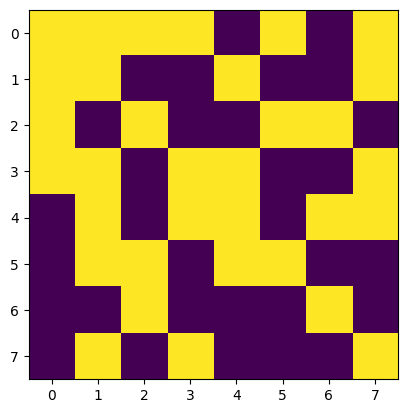

In [210]:
plt.imshow(M[0])

In [211]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [212]:
M[1]@M[0]

array([[3, 4, 4, 2, 3, 3, 3, 3],
       [2, 2, 1, 1, 1, 1, 0, 2],
       [0, 2, 2, 1, 1, 1, 1, 1],
       [3, 5, 2, 4, 3, 1, 2, 5],
       [2, 2, 3, 2, 1, 2, 3, 2],
       [3, 5, 2, 3, 4, 2, 2, 4],
       [3, 4, 3, 4, 2, 2, 3, 4],
       [2, 3, 1, 3, 2, 1, 1, 3]])

In [213]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

In [214]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]]))

In [215]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [216]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

In [217]:
M

[array([[1, 1, 1, 1, 0, 1, 0, 1],
        [1, 1, 0, 0, 1, 0, 0, 1],
        [1, 0, 1, 0, 0, 1, 1, 0],
        [1, 1, 0, 1, 1, 0, 0, 1],
        [0, 1, 0, 1, 1, 0, 1, 1],
        [0, 1, 1, 0, 1, 1, 0, 0],
        [0, 0, 1, 0, 0, 0, 1, 0],
        [0, 1, 0, 1, 0, 0, 0, 1]]),
 array([[1, 1, 1, 0, 1, 1, 1, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [1, 1, 0, 1, 1, 0, 1, 1],
        [1, 0, 1, 0, 1, 0, 1, 0],
        [0, 1, 1, 1, 1, 1, 0, 1],
        [1, 0, 1, 1, 1, 0, 1, 1],
        [1, 0, 0, 1, 1, 0, 0, 0]])]

In [218]:
M_p[0]

array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

In [219]:
M_p[1]

array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]])

In [220]:
def send_matrix(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [221]:
len(str("0000000000000009"))*4


64

In [222]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

In [223]:
M_p[1]

array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])

In [224]:
print_matrix(M[0]@M[1])

4 4 2 3 4 3 3 3 
4 2 2 1 3 1 2 0 
2 2 3 2 3 3 3 3 
5 3 2 2 4 1 3 1 
5 2 2 3 4 0 3 2 
2 2 2 1 2 2 2 2 
1 0 1 1 1 1 2 2 
3 2 0 2 2 0 1 1 


In [225]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

In [226]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]]),
 array([[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])]

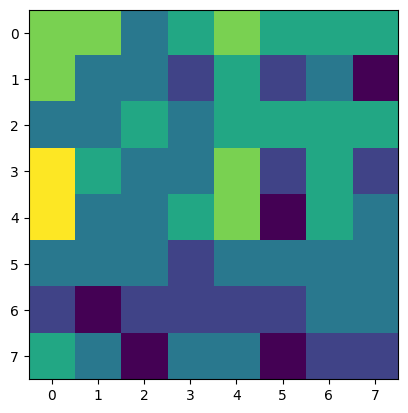

In [227]:
plt.imshow(M[0]@M[1])

plt.show()

In [228]:

for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A",0)
    send_matrix(M_p[1],"INPUT_B",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [229]:
M[0]

array([[1, 1, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 0, 1, 0, 0, 1],
       [1, 0, 1, 0, 0, 1, 1, 0],
       [1, 1, 0, 1, 1, 0, 0, 1],
       [0, 1, 0, 1, 1, 0, 1, 1],
       [0, 1, 1, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 0, 0, 1, 0],
       [0, 1, 0, 1, 0, 0, 0, 1]])

In [230]:
M[1]

array([[1, 1, 1, 0, 1, 1, 1, 0],
       [1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 1],
       [1, 1, 0, 1, 1, 0, 1, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [1, 0, 1, 1, 1, 0, 1, 1],
       [1, 0, 0, 1, 1, 0, 0, 0]])

In [231]:
M[0]@M[1]

array([[4, 4, 2, 3, 4, 3, 3, 3],
       [4, 2, 2, 1, 3, 1, 2, 0],
       [2, 2, 3, 2, 3, 3, 3, 3],
       [5, 3, 2, 2, 4, 1, 3, 1],
       [5, 2, 2, 3, 4, 0, 3, 2],
       [2, 2, 2, 1, 2, 2, 2, 2],
       [1, 0, 1, 1, 1, 1, 2, 2],
       [3, 2, 0, 2, 2, 0, 1, 1]])

In [232]:
s = serial.Serial()

s.port = "/dev/ttyUSB1"
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [233]:
i =1
s.write(bytearray([int(i)]))


1

In [234]:
serial.Serial()

Serial<id=0x7fb92a202e30, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)